> **Weather-aware workflow note:** The saved ML models are evaluated with the same weather-aware feature columns used during training. Only weather available at input time t is used; target-time weather is excluded.

In [1]:
# What this cell does:
# Import all libraries required for final model evaluation,
# visualization, metrics, and loading the trained models.

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# What this cell does:
# Load the final engineered datasets created in Notebook 05.
# These datasets contain the 14 ML features and TARGET_AC_POWER.

plant1 = pd.read_csv("../data/final/plant1_features.csv")
plant2 = pd.read_csv("../data/final/plant2_features.csv")

plant1["DATE_TIME"] = pd.to_datetime(plant1["DATE_TIME"])
plant2["DATE_TIME"] = pd.to_datetime(plant2["DATE_TIME"])

print("Plant 1 shape:", plant1.shape)
print("Plant 2 shape:", plant2.shape)

Plant 1 shape: (66337, 27)
Plant 2 shape: (65466, 27)


In [3]:
# What this cell does:
# Define the exact feature set and target used during model training.
# Keeping the same feature order is important when loading saved models.

feature_columns = [
    "hour",
    "minute",
    "day",
    "day_of_week",
    "day_of_year",
    "month",
    "hour_sin",
    "hour_cos",
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "AC_POWER_lag_1",
    "AC_POWER_lag_4",
    "AC_POWER_lag_8",
    "AC_POWER_lag_96",
    "AC_POWER_rolling_mean_4",
    "AC_POWER_rolling_mean_8"
]

target_column = "TARGET_AC_POWER"

print("Number of features:", len(feature_columns))
print("Target:", target_column)

Number of features: 17
Target: TARGET_AC_POWER


In [4]:
# What this cell does:
# Recreate the exact chronological train/validation/test split
# used during model training.
#
# No random shuffling is used because this is a time-series problem.

def chronological_split(df, train_ratio=0.70, val_ratio=0.15):
    """Split chronologically and remove rows whose target crosses a cutoff."""
    df = df.sort_values("DATE_TIME").copy()
    unique_times = np.sort(df["DATE_TIME"].unique())
    n_times = len(unique_times)
    train_end = int(n_times * train_ratio)
    val_end = int(n_times * (train_ratio + val_ratio))
    train_end_time = pd.Timestamp(unique_times[train_end])
    val_end_time = pd.Timestamp(unique_times[val_end])
    target_time = df["DATE_TIME"] + pd.Timedelta(minutes=15)

    train = df[(df["DATE_TIME"] < train_end_time) & (target_time < train_end_time)].copy()
    validation = df[
        (df["DATE_TIME"] >= train_end_time)
        & (df["DATE_TIME"] < val_end_time)
        & (target_time < val_end_time)
    ].copy()
    test = df[df["DATE_TIME"] >= val_end_time].copy()
    return train, validation, test

In [5]:
# What this cell does:
# Create the final unseen test datasets for both plants.
# Only the test period will be used for final model evaluation.

plant1_train, plant1_val, plant1_test = chronological_split(plant1)
plant2_train, plant2_val, plant2_test = chronological_split(plant2)

print("Plant 1 test:", plant1_test.shape)
print("Plant 2 test:", plant2_test.shape)

print("\nPlant 1 test period:")
print(
    plant1_test["DATE_TIME"].min(),
    "→",
    plant1_test["DATE_TIME"].max()
)

print("\nPlant 2 test period:")
print(
    plant2_test["DATE_TIME"].min(),
    "→",
    plant2_test["DATE_TIME"].max()
)

Plant 1 test: (10076, 27)
Plant 2 test: (10428, 27)

Plant 1 test period:
2020-06-13 04:30:00 → 2020-06-17 23:30:00

Plant 2 test period:
2020-06-13 01:15:00 → 2020-06-17 23:30:00


In [6]:
# What this cell does:
# Extract the 17 input features and the target variable
# from the untouched test period.

X1_test = plant1_test[feature_columns]
y1_test = plant1_test[target_column]

X2_test = plant2_test[feature_columns]
y2_test = plant2_test[target_column]

print("Plant 1 X_test:", X1_test.shape)
print("Plant 1 y_test:", y1_test.shape)

print("\nPlant 2 X_test:", X2_test.shape)
print("Plant 2 y_test:", y2_test.shape)

Plant 1 X_test: (10076, 17)
Plant 1 y_test: (10076,)

Plant 2 X_test: (10428, 17)
Plant 2 y_test: (10428,)


In [7]:
# What this cell does:
# Load the trained Linear Regression, Random Forest,
# and XGBoost models saved from Notebook 07.
#
# We load the models instead of retraining them.

MODEL_PATH = "../models/"

linear_model_plant1 = joblib.load(
    MODEL_PATH + "linear_regression/plant1_model.pkl"
)

linear_model_plant2 = joblib.load(
    MODEL_PATH + "linear_regression/plant2_model.pkl"
)

rf_model_plant1 = joblib.load(
    MODEL_PATH + "random_forest/plant1_model.pkl"
)

rf_model_plant2 = joblib.load(
    MODEL_PATH + "random_forest/plant2_model.pkl"
)

xgb_model_plant1 = joblib.load(
    MODEL_PATH + "xgboost/plant1_model.pkl"
)

xgb_model_plant2 = joblib.load(
    MODEL_PATH + "xgboost/plant2_model.pkl"
)

print("All trained models loaded successfully.")

All trained models loaded successfully.


In [8]:
# What this cell does:
# Generate final predictions on the completely unseen test period
# using all three trained ML models.

# Plant 1
plant1_test["Persistence"] = plant1_test["AC_POWER"]

plant1_test["Linear_Regression"] = (
    linear_model_plant1.predict(X1_test)
)

plant1_test["Random_Forest"] = (
    rf_model_plant1.predict(X1_test)
)

plant1_test["XGBoost"] = (
    xgb_model_plant1.predict(X1_test)
)


# Plant 2
plant2_test["Persistence"] = plant2_test["AC_POWER"]

plant2_test["Linear_Regression"] = (
    linear_model_plant2.predict(X2_test)
)

plant2_test["Random_Forest"] = (
    rf_model_plant2.predict(X2_test)
)

plant2_test["XGBoost"] = (
    xgb_model_plant2.predict(X2_test)
)

print("Test predictions generated successfully.")

Test predictions generated successfully.


In [9]:
# What this cell does:
# Check that every model produced the expected number of
# predictions and inspect a few actual versus predicted values.

print("Plant 1:")
display(
    plant1_test[
        [
            "DATE_TIME",
            "TARGET_AC_POWER",
            "Persistence",
            "Linear_Regression",
            "Random_Forest",
            "XGBoost"
        ]
    ].head()
)

print("\nPlant 2:")
display(
    plant2_test[
        [
            "DATE_TIME",
            "TARGET_AC_POWER",
            "Persistence",
            "Linear_Regression",
            "Random_Forest",
            "XGBoost"
        ]
    ].head()
)

Plant 1:


,DATE_TIME,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost
2589,2020-06-13 04:30:00,0.0,0.0,45.931543,0.0,0.731793
23665,2020-06-13 04:30:00,0.0,0.0,45.931543,0.0,0.731793
14641,2020-06-13 04:30:00,0.0,0.0,45.931543,0.0,0.731793
56848,2020-06-13 04:30:00,0.0,0.0,45.931543,0.0,0.731793
35752,2020-06-13 04:30:00,0.0,0.0,45.931543,0.0,0.731793



Plant 2:


,DATE_TIME,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost
20597,2020-06-13 01:15:00,0.0,0.0,-14.874999,0.0,0.055398
59581,2020-06-13 01:15:00,0.0,0.0,-14.874999,0.0,0.055398
50107,2020-06-13 01:15:00,0.0,0.0,-14.874999,0.0,0.055398
32194,2020-06-13 01:15:00,0.0,0.0,-14.874999,0.0,0.055398
8935,2020-06-13 01:15:00,0.0,0.0,-14.874999,0.0,0.055398


In [10]:
# What this cell does:
# Evaluate all forecasting approaches on the completely unseen
# test period using MAE, RMSE and R².

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


# Plant 1
p1_persistence = calculate_metrics(
    y1_test, plant1_test["Persistence"]
)

p1_linear = calculate_metrics(
    y1_test, plant1_test["Linear_Regression"]
)

p1_rf = calculate_metrics(
    y1_test, plant1_test["Random_Forest"]
)

p1_xgb = calculate_metrics(
    y1_test, plant1_test["XGBoost"]
)


# Plant 2
p2_persistence = calculate_metrics(
    y2_test, plant2_test["Persistence"]
)

p2_linear = calculate_metrics(
    y2_test, plant2_test["Linear_Regression"]
)

p2_rf = calculate_metrics(
    y2_test, plant2_test["Random_Forest"]
)

p2_xgb = calculate_metrics(
    y2_test, plant2_test["XGBoost"]
)


print("Plant 1 - Test Results")
print("Persistence       MAE:", p1_persistence[0],
      "RMSE:", p1_persistence[1],
      "R²:", p1_persistence[2])

print("Linear Regression MAE:", p1_linear[0],
      "RMSE:", p1_linear[1],
      "R²:", p1_linear[2])

print("Random Forest     MAE:", p1_rf[0],
      "RMSE:", p1_rf[1],
      "R²:", p1_rf[2])

print("XGBoost           MAE:", p1_xgb[0],
      "RMSE:", p1_xgb[1],
      "R²:", p1_xgb[2])


print("\nPlant 2 - Test Results")
print("Persistence       MAE:", p2_persistence[0],
      "RMSE:", p2_persistence[1],
      "R²:", p2_persistence[2])

print("Linear Regression MAE:", p2_linear[0],
      "RMSE:", p2_linear[1],
      "R²:", p2_linear[2])

print("Random Forest     MAE:", p2_rf[0],
      "RMSE:", p2_rf[1],
      "R²:", p2_rf[2])

print("XGBoost           MAE:", p2_xgb[0],
      "RMSE:", p2_xgb[1],
      "R²:", p2_xgb[2])

Plant 1 - Test Results
Persistence       MAE: 60.149400095316196 RMSE: 113.23179349217021 R²: 0.9112735485175332
Linear Regression MAE: 67.29376395662646 RMSE: 110.66877401259606 R²: 0.9152447638958603
Random Forest     MAE: 67.52815098261583 RMSE: 131.6823405853613 R²: 0.880002716415546
XGBoost           MAE: 65.36155779232801 RMSE: 129.558902461745 R²: 0.8838415359151311

Plant 2 - Test Results
Persistence       MAE: 64.05312181489397 RMSE: 132.3360489385585 R²: 0.8029120790256988
Linear Regression MAE: 81.55208177532609 RMSE: 148.3437179930298 R²: 0.7523479088412839
Random Forest     MAE: 68.53869516023222 RMSE: 141.01839676496985 R²: 0.7762025025386767
XGBoost           MAE: 68.81797250720224 RMSE: 142.87422257343252 R²: 0.7702733176647985


In [11]:
# What this cell does:
# Put all final test metrics into one clean table.

test_results = pd.DataFrame({
    "Plant": [
        "Plant 1", "Plant 1", "Plant 1", "Plant 1",
        "Plant 2", "Plant 2", "Plant 2", "Plant 2"
    ],

    "Model": [
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        p1_persistence[0],
        p1_linear[0],
        p1_rf[0],
        p1_xgb[0],
        p2_persistence[0],
        p2_linear[0],
        p2_rf[0],
        p2_xgb[0]
    ],

    "RMSE": [
        p1_persistence[1],
        p1_linear[1],
        p1_rf[1],
        p1_xgb[1],
        p2_persistence[1],
        p2_linear[1],
        p2_rf[1],
        p2_xgb[1]
    ],

    "R2": [
        p1_persistence[2],
        p1_linear[2],
        p1_rf[2],
        p1_xgb[2],
        p2_persistence[2],
        p2_linear[2],
        p2_rf[2],
        p2_xgb[2]
    ]
})

test_results

,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.149400,113.231793,0.911274
1,Plant 1,Linear Regression,67.293764,110.668774,0.915245
2,Plant 1,Random Forest,67.528151,131.682341,0.880003
3,Plant 1,XGBoost,65.361558,129.558902,0.883842
4,Plant 2,Persistence,64.053122,132.336049,0.802912
5,Plant 2,Linear Regression,81.552082,148.343718,0.752348
6,Plant 2,Random Forest,68.538695,141.018397,0.776203
7,Plant 2,XGBoost,68.817973,142.874223,0.770273


In [12]:
# What this cell does:
# Save the final test metrics for the report and later notebooks.

METRICS_PATH = "../outputs/metrics/"
os.makedirs(METRICS_PATH, exist_ok=True)

test_results.to_csv(
    METRICS_PATH + "test_model_results.csv",
    index=False
)

print("Final test metrics saved successfully.")

Final test metrics saved successfully.


In [13]:
# What this cell does:
# Save actual target values and all model predictions.
# These predictions will be used for residual analysis,
# actual-vs-predicted plots, and time-based evaluation.

PREDICTIONS_PATH = "../outputs/predictions/"
os.makedirs(PREDICTIONS_PATH, exist_ok=True)

plant1_test[
    [
        "DATE_TIME",
        "PLANT_ID",
        "SOURCE_KEY",
        "AC_POWER",
        "TARGET_AC_POWER",
        "Persistence",
        "Linear_Regression",
        "Random_Forest",
        "XGBoost"
    ]
].to_csv(
    PREDICTIONS_PATH + "plant1_test_predictions.csv",
    index=False
)

plant2_test[
    [
        "DATE_TIME",
        "PLANT_ID",
        "SOURCE_KEY",
        "AC_POWER",
        "TARGET_AC_POWER",
        "Persistence",
        "Linear_Regression",
        "Random_Forest",
        "XGBoost"
    ]
].to_csv(
    PREDICTIONS_PATH + "plant2_test_predictions.csv",
    index=False
)

print("Test predictions saved successfully.")

Test predictions saved successfully.


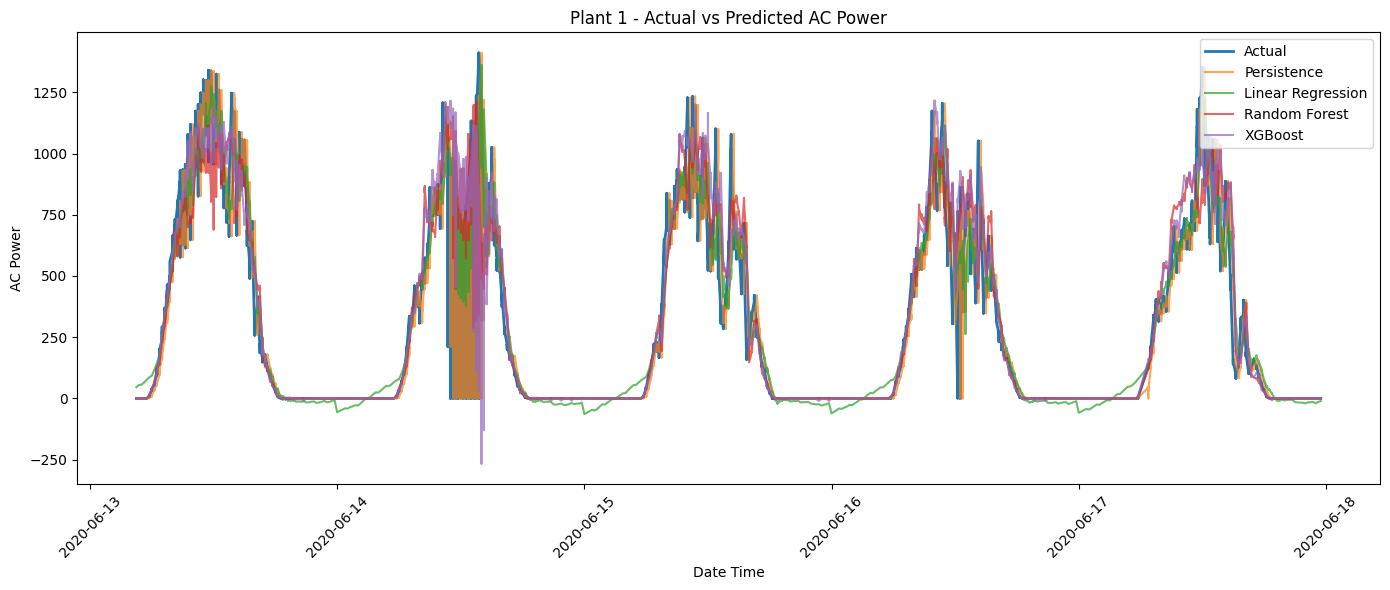

In [14]:
# What this cell does:
# Compare actual 15-minute-ahead AC power with predictions
# from Persistence, Linear Regression, Random Forest and XGBoost.

plt.figure(figsize=(14, 6))

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["TARGET_AC_POWER"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Persistence"],
    label="Persistence",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Linear_Regression"],
    label="Linear Regression",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Random_Forest"],
    label="Random Forest",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["XGBoost"],
    label="XGBoost",
    alpha=0.7
)

plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.title("Plant 1 - Actual vs Predicted AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

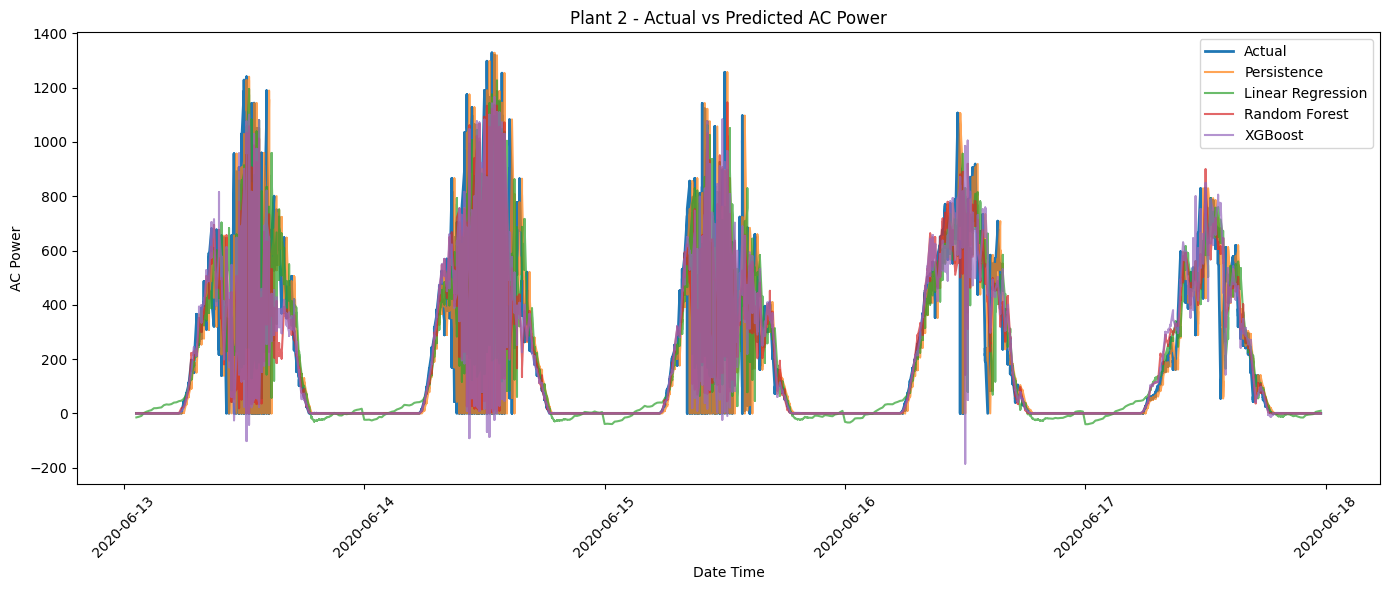

In [15]:
# What this cell does:
# Compare actual and predicted AC power for Plant 2.

plt.figure(figsize=(14, 6))

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["TARGET_AC_POWER"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Persistence"],
    label="Persistence",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Linear_Regression"],
    label="Linear Regression",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Random_Forest"],
    label="Random Forest",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["XGBoost"],
    label="XGBoost",
    alpha=0.7
)

plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.title("Plant 2 - Actual vs Predicted AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# What this cell does:
# Calculate prediction errors (residuals) for every model.
#
# Residual = Actual - Predicted
#
# A residual close to zero means the prediction is close
# to the actual AC power.

# Plant 1
plant1_test["Persistence_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Persistence"]
)

plant1_test["Linear_Regression_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Linear_Regression"]
)

plant1_test["Random_Forest_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Random_Forest"]
)

plant1_test["XGBoost_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["XGBoost"]
)


# Plant 2
plant2_test["Persistence_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Persistence"]
)

plant2_test["Linear_Regression_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Linear_Regression"]
)

plant2_test["Random_Forest_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Random_Forest"]
)

plant2_test["XGBoost_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["XGBoost"]
)

print("Residuals calculated successfully.")

Residuals calculated successfully.


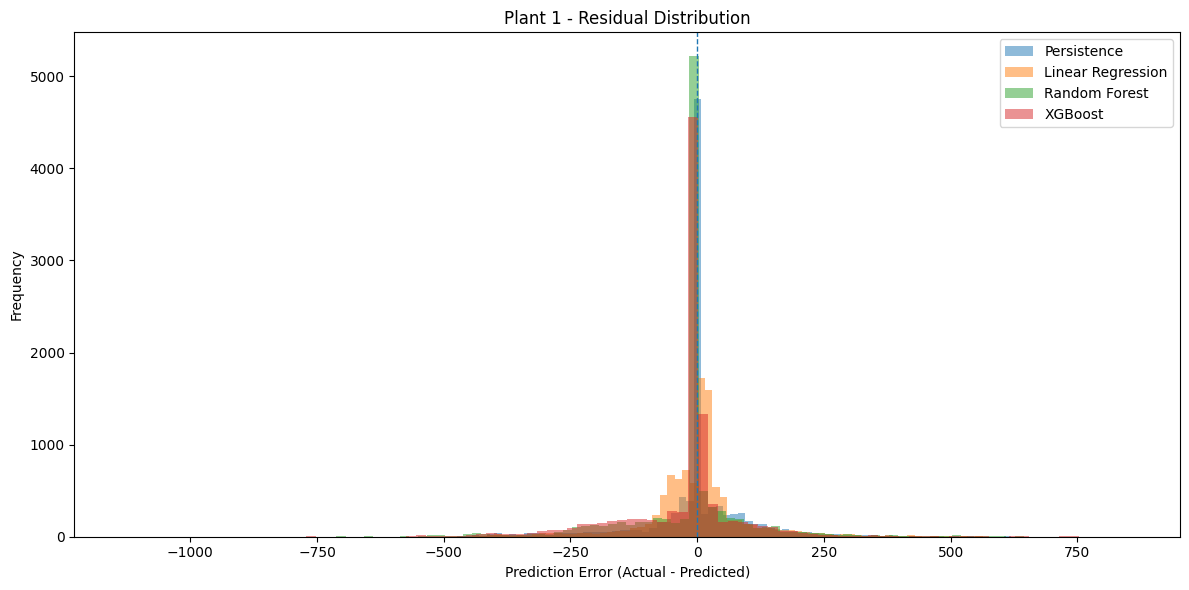

In [17]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 1.

plt.figure(figsize=(12, 6))

plt.hist(
    plant1_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant1_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant1_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant1_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 1 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

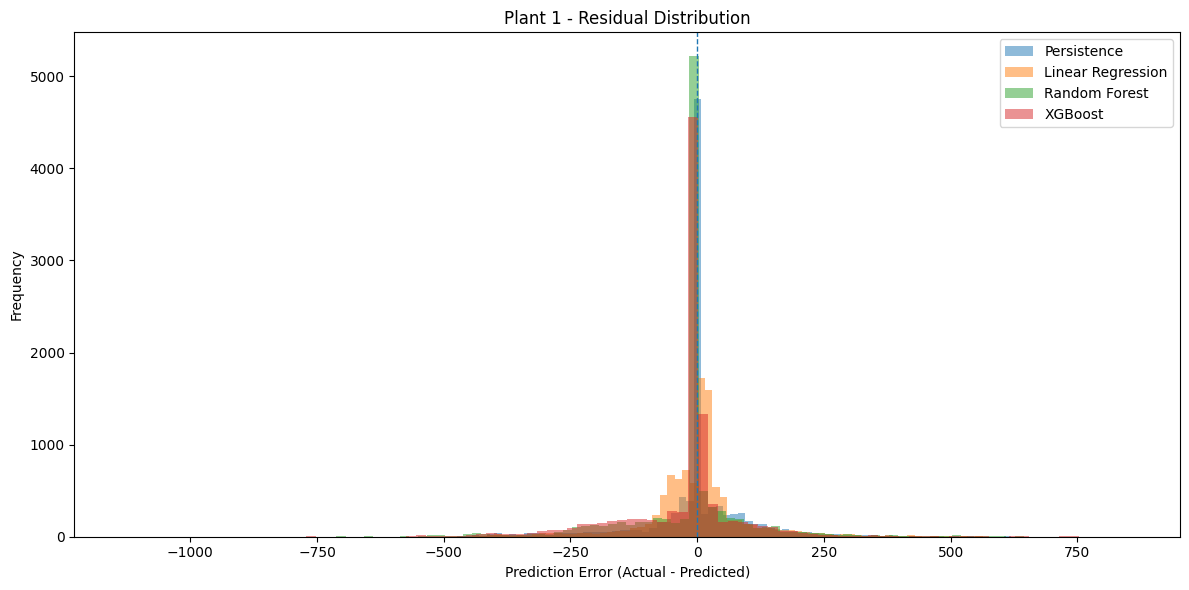

In [18]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 1.

plt.figure(figsize=(12, 6))

plt.hist(
    plant1_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant1_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant1_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant1_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 1 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

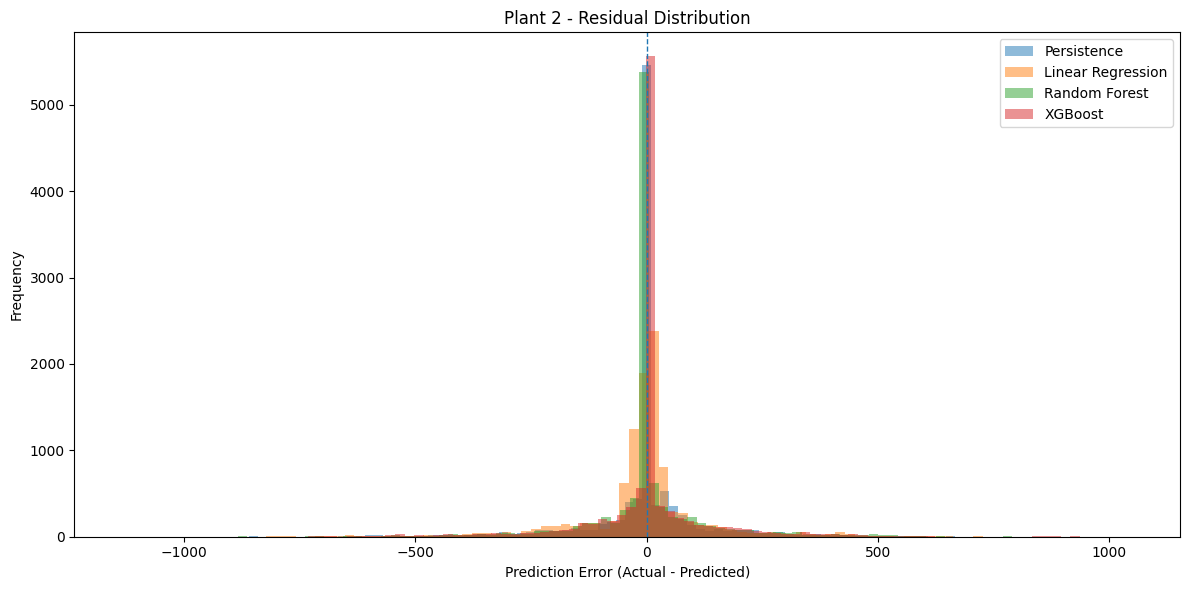

In [19]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 2.

plt.figure(figsize=(12, 6))

plt.hist(
    plant2_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant2_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant2_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant2_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 2 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

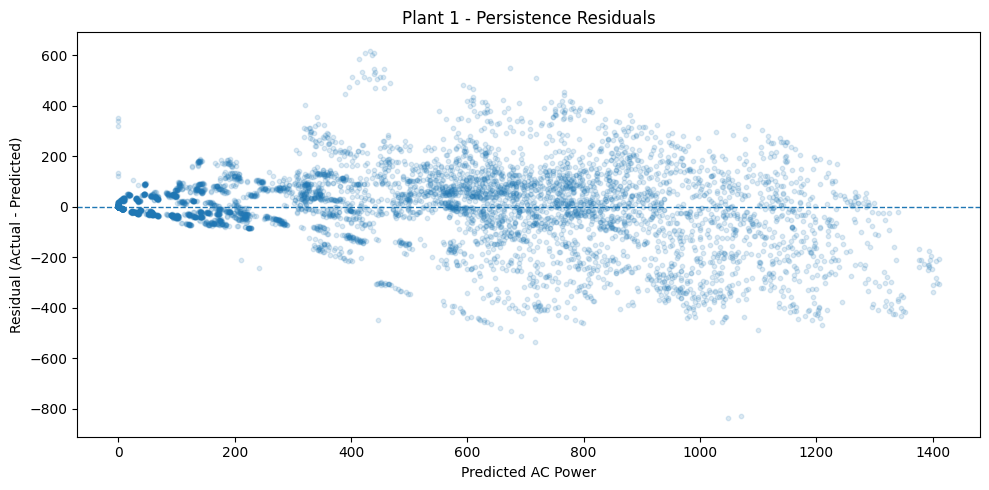

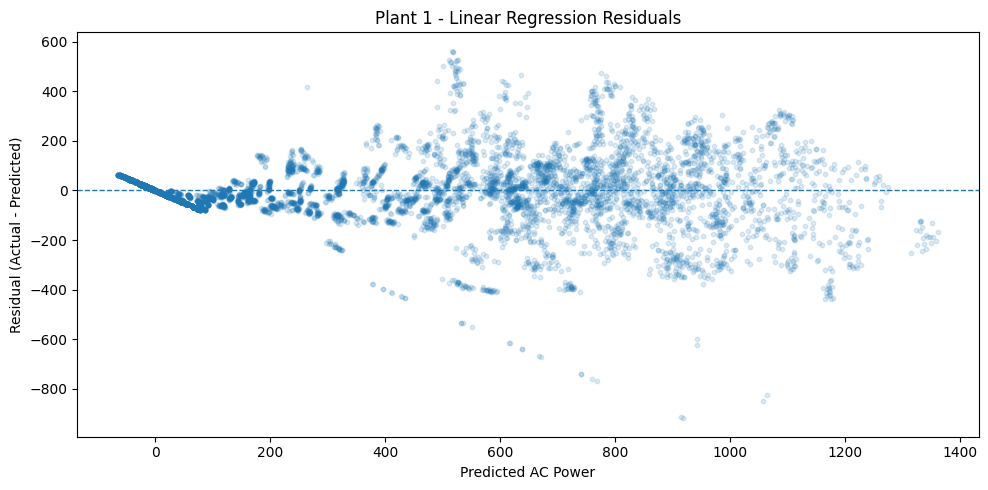

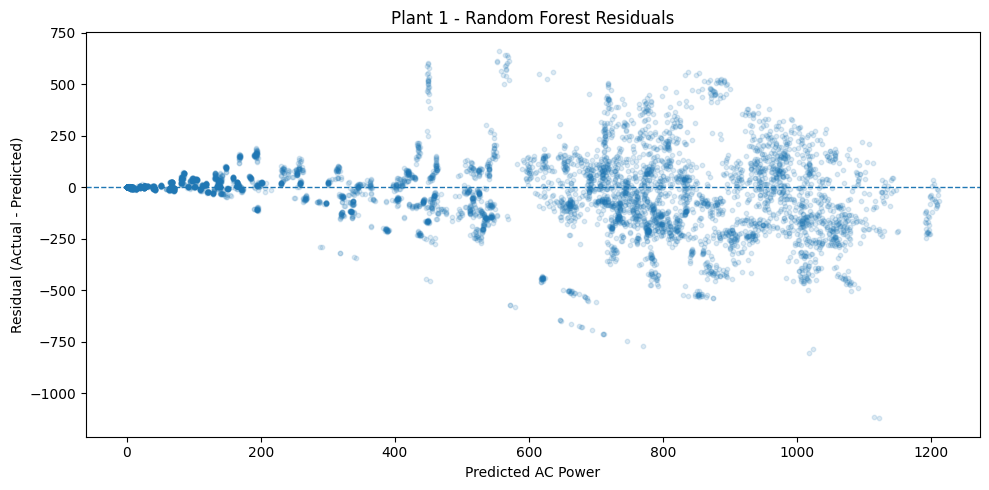

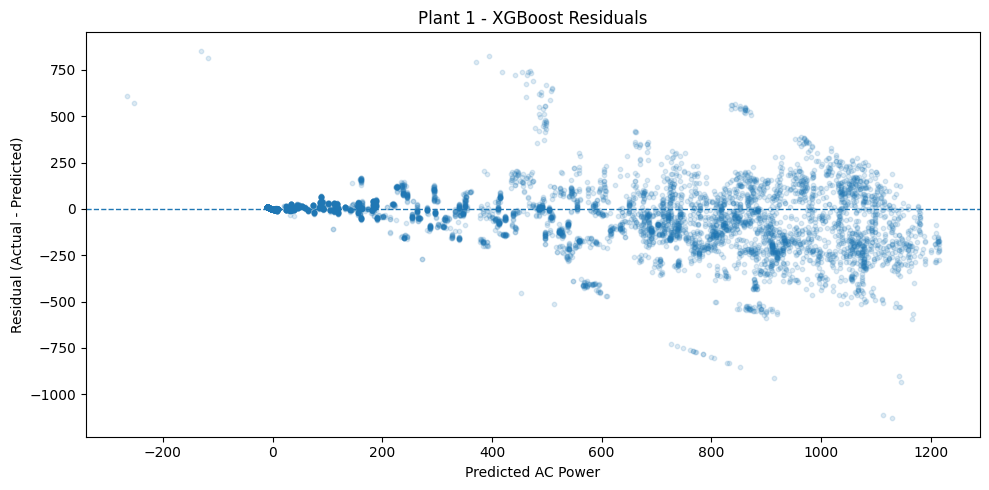

In [20]:
# What this cell does:
# Plot prediction residuals against predicted AC power.
#
# Residual = Actual - Predicted
#
# This helps us identify whether errors increase
# when the predicted solar power becomes higher.

models = [
    ("Persistence", "Persistence", "Persistence_Error"),
    ("Linear Regression", "Linear_Regression", "Linear_Regression_Error"),
    ("Random Forest", "Random_Forest", "Random_Forest_Error"),
    ("XGBoost", "XGBoost", "XGBoost_Error")
]

for model_name, prediction_column, error_column in models:

    plt.figure(figsize=(10, 5))

    plt.scatter(
        plant1_test[prediction_column],
        plant1_test[error_column],
        alpha=0.15,
        s=10
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Predicted AC Power")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Plant 1 - {model_name} Residuals")
    plt.tight_layout()
    plt.show()

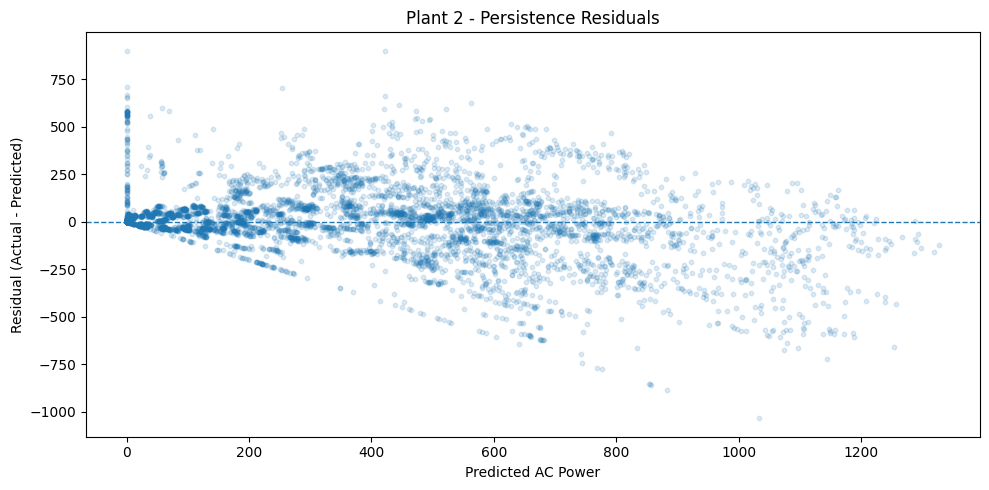

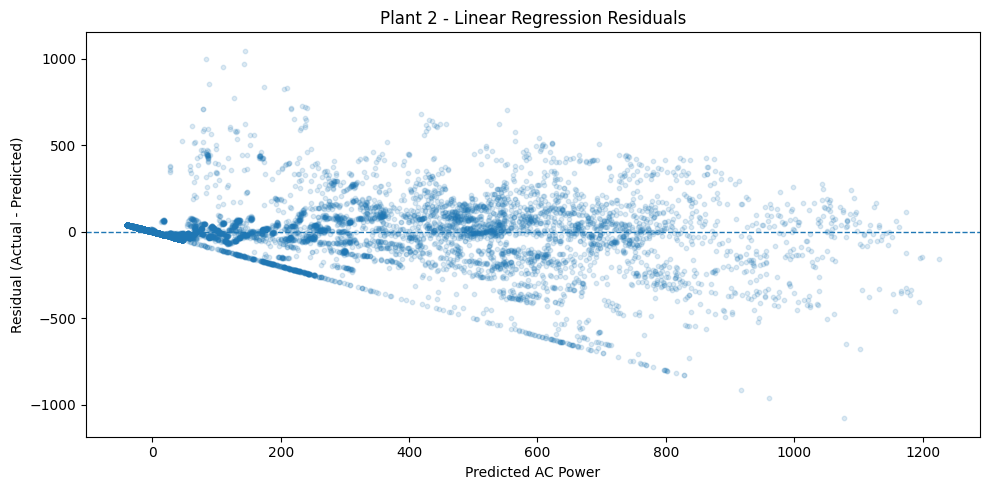

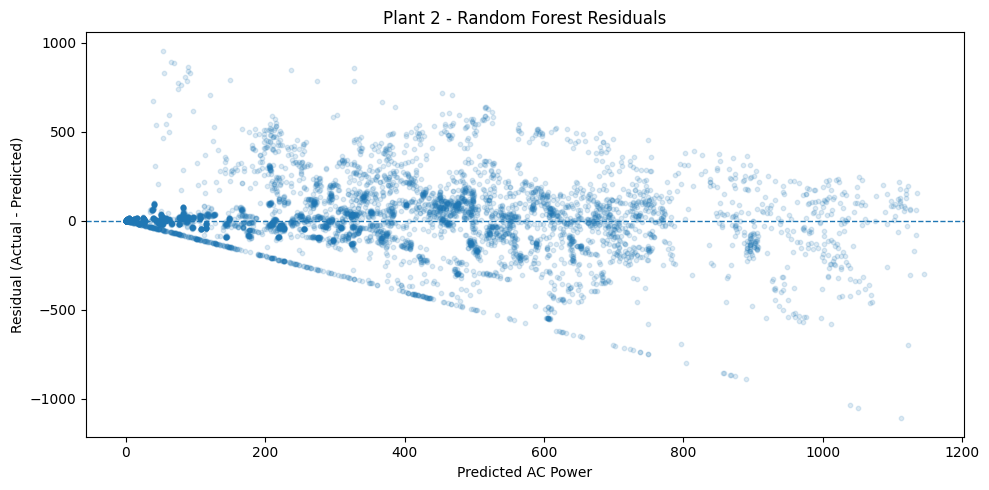

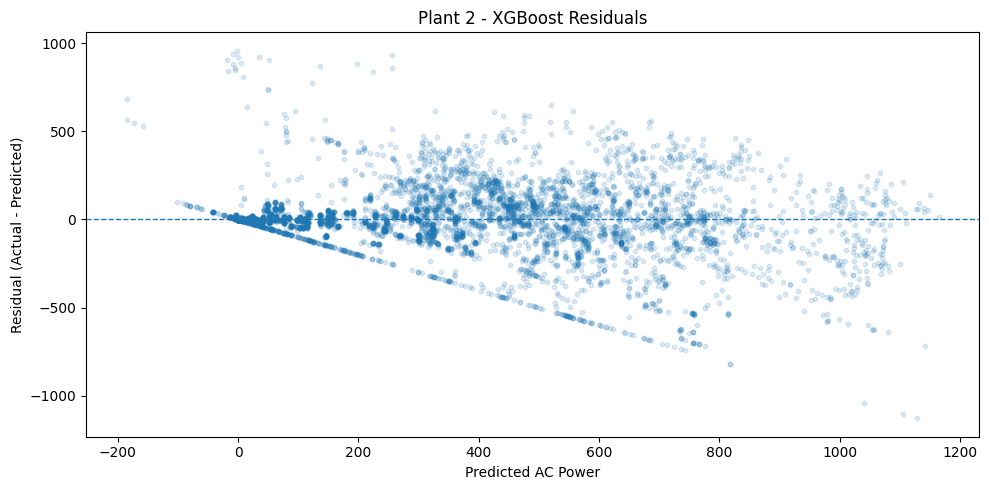

In [21]:
# What this cell does:
# Plot residuals against predicted AC power for Plant 2.
#
# We check whether prediction errors change
# with the level of predicted solar generation.

for model_name, prediction_column, error_column in models:

    plt.figure(figsize=(10, 5))

    plt.scatter(
        plant2_test[prediction_column],
        plant2_test[error_column],
        alpha=0.15,
        s=10
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Predicted AC Power")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Plant 2 - {model_name} Residuals")
    plt.tight_layout()
    plt.show()

In [22]:
# What this cell does:
# Calculate model MAE separately for every hour of the day.
# This helps identify when the forecasting models make
# larger errors.

plant1_hourly = plant1_test.copy()

plant1_hourly["hour"] = plant1_hourly["DATE_TIME"].dt.hour

hourly_mae_p1 = plant1_hourly.groupby("hour").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"], df["XGBoost"]
        )
    })
)

hourly_mae_p1

,Persistence,Linear Regression,Random Forest,XGBoost
hour,,,,
0,0.000000,51.258020,0.000000,0.187365
1,0.000000,35.329623,0.000000,0.248036
2,0.000000,15.313021,0.000000,0.449137
3,0.000000,10.904870,0.000000,0.731793
4,0.000000,37.234882,0.000000,0.731793
5,1.178649,63.441386,1.342955,1.691341
6,46.148907,31.366388,13.170312,13.520987
7,83.045296,56.122179,58.912281,50.956543
8,63.174383,58.712708,115.053351,87.582181


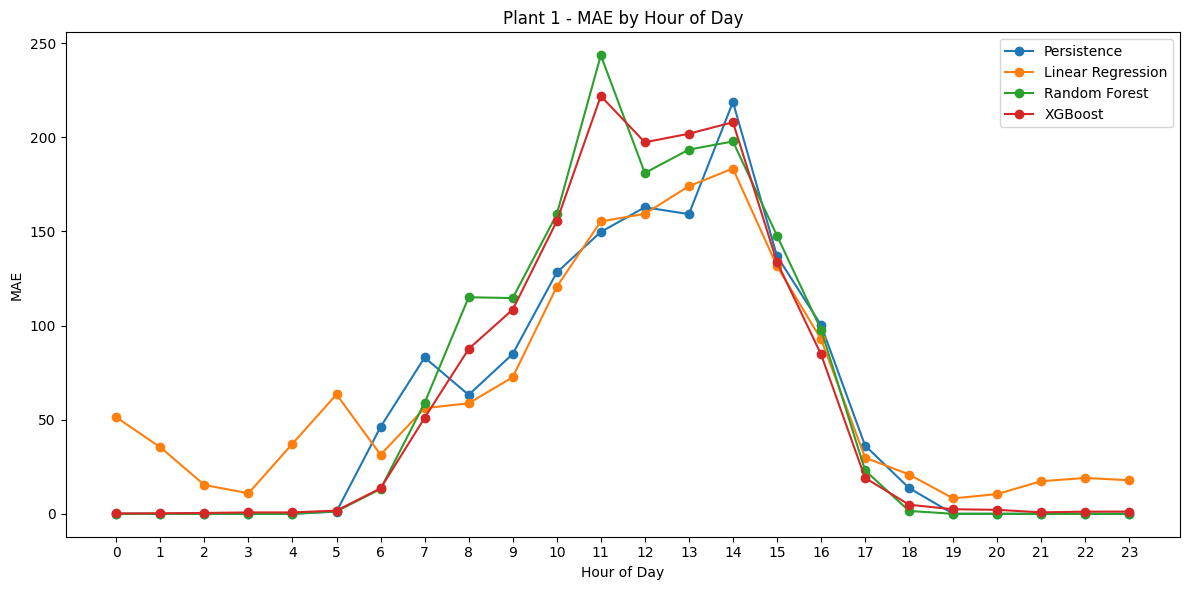

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Hour of Day")
plt.ylabel("MAE")
plt.title("Plant 1 - MAE by Hour of Day")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# What this cell does:
# Calculate MAE for each hour of the day for Plant 2.

plant2_hourly = plant2_test.copy()

plant2_hourly["hour"] = plant2_hourly["DATE_TIME"].dt.hour

hourly_mae_p2 = plant2_hourly.groupby("hour").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"], df["XGBoost"]
        )
    })
)

hourly_mae_p2

,Persistence,Linear Regression,Random Forest,XGBoost
hour,,,,
0,0.000000,33.216399,0.000000,0.055398
1,0.000000,20.214569,0.000000,0.106689
2,0.000000,6.572335,0.000000,0.594454
3,0.000000,14.790313,0.000000,0.265249
4,0.000000,30.742047,0.000000,0.270608
5,1.771114,40.790502,1.496919,1.242996
6,39.849561,28.455250,21.718105,19.705936
7,59.631212,51.369266,49.610977,44.612589
8,100.218523,103.703306,119.223275,116.364169


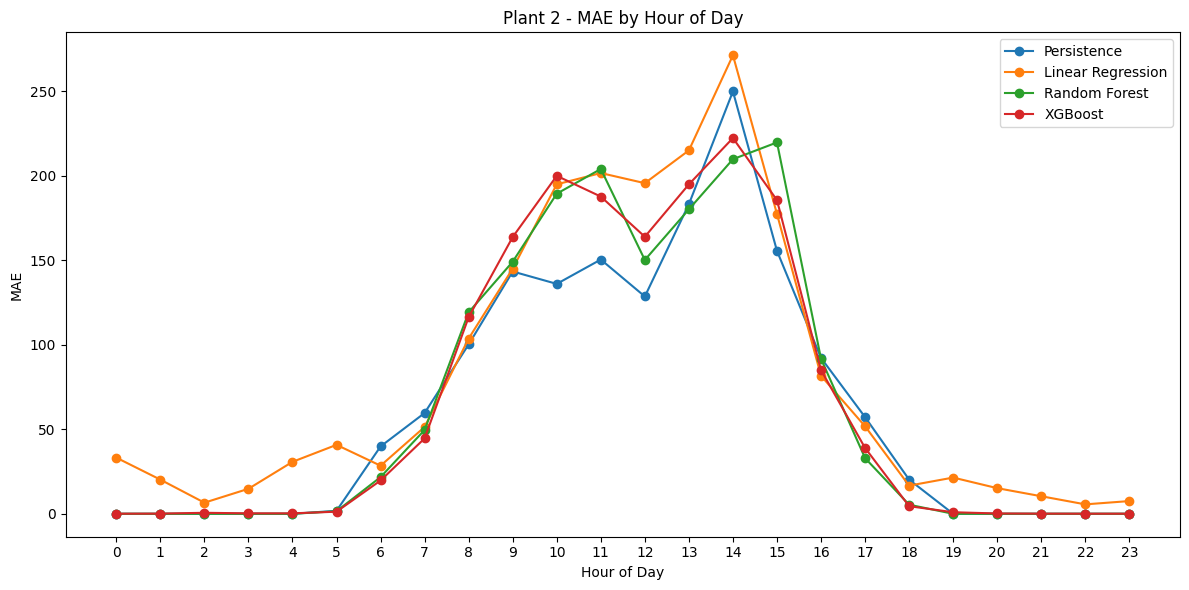

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Hour of Day")
plt.ylabel("MAE")
plt.title("Plant 2 - MAE by Hour of Day")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# What this cell does:
# Divide Plant 1 test observations into irradiation ranges
# and calculate model MAE for each range.

plant1_irr = plant1_test.copy()

plant1_irr["irradiation_level"] = pd.cut(
    plant1_irr["IRRADIATION"],
    bins=[-0.001, 0.05, 0.2, 0.5, 1.0, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

irradiation_mae_p1 = plant1_irr.groupby(
    "irradiation_level",
    observed=True
).apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

irradiation_mae_p1

,Persistence,Linear Regression,Random Forest,XGBoost
irradiation_level,,,,
Very Low,3.363713,25.961957,0.736178,1.894038
Low,55.823022,50.015867,45.825463,39.433782
Medium,116.597218,101.332992,137.363300,130.950706
High,150.551077,147.173996,176.685340,172.725824
Very High,233.047673,179.970344,343.591012,320.175106


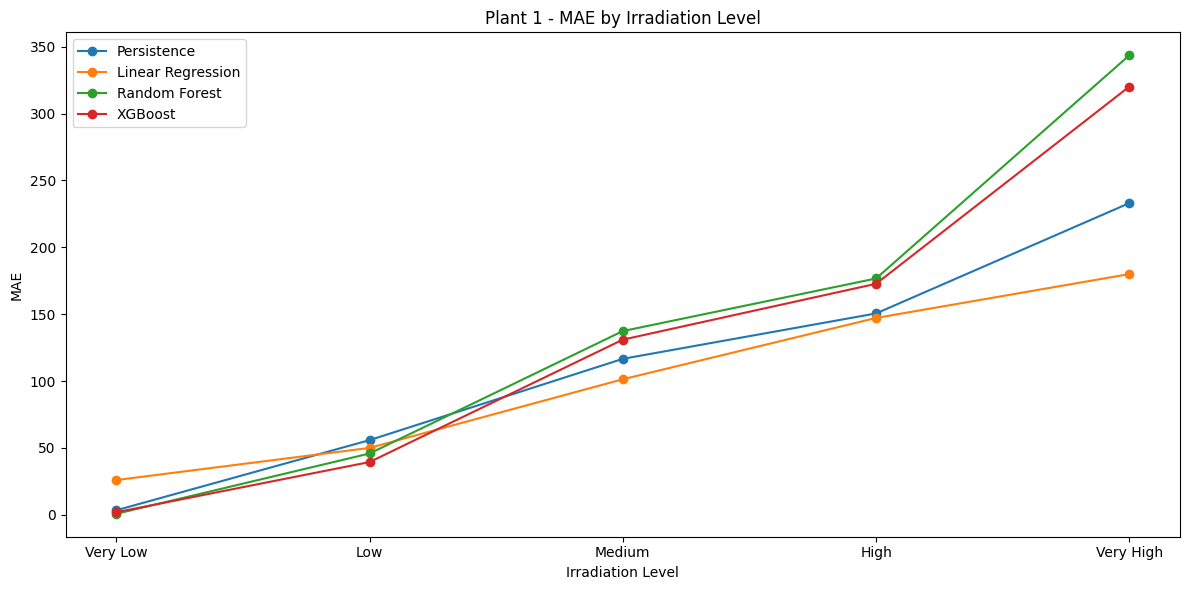

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Irradiation Level")
plt.ylabel("MAE")
plt.title("Plant 1 - MAE by Irradiation Level")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# What this cell does:
# Calculate model MAE for different irradiation levels
# for Plant 2.

plant2_irr = plant2_test.copy()

plant2_irr["irradiation_level"] = pd.cut(
    plant2_irr["IRRADIATION"],
    bins=[-0.001, 0.05, 0.2, 0.5, 1.0, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

irradiation_mae_p2 = plant2_irr.groupby(
    "irradiation_level",
    observed=True
).apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

irradiation_mae_p2

,Persistence,Linear Regression,Random Forest,XGBoost
irradiation_level,,,,
Very Low,3.323732,18.609288,2.219754,2.294296
Low,63.776236,58.832179,48.067116,50.058644
Medium,148.684414,159.428550,160.159502,159.083679
High,159.833325,217.295758,192.725342,194.466252


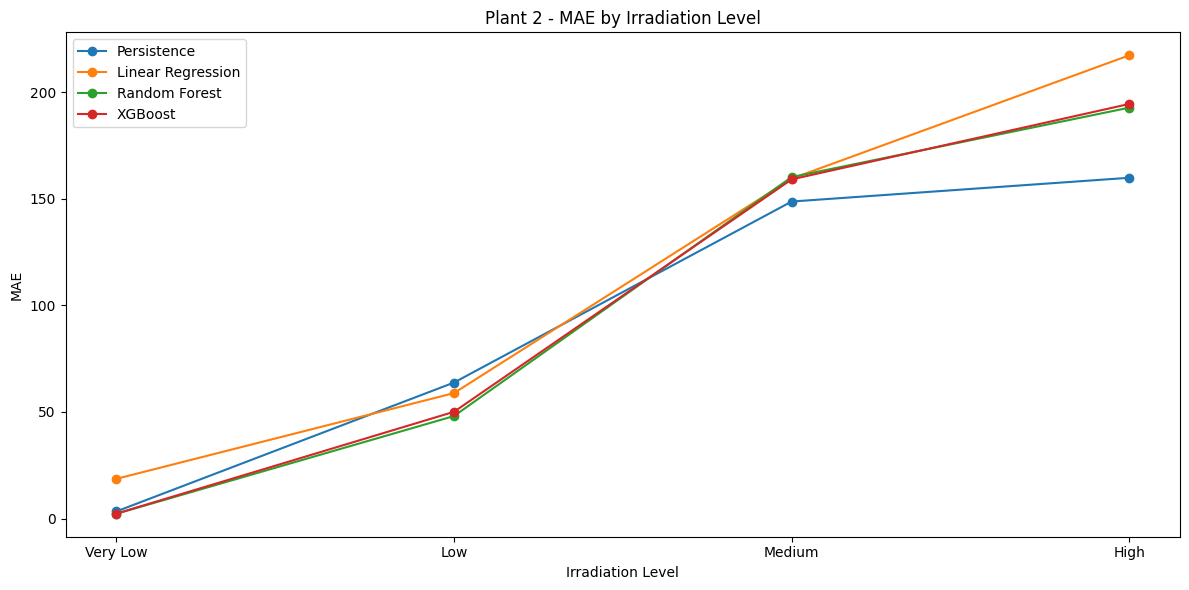

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Irradiation Level")
plt.ylabel("MAE")
plt.title("Plant 2 - MAE by Irradiation Level")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# What this cell does:
# Calculate MAE for each inverter (SOURCE_KEY)
# for all forecasting models on Plant 1 test data.

plant1_inverter_mae = plant1_test.groupby("SOURCE_KEY").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

plant1_inverter_mae

,Persistence,Linear Regression,Random Forest,XGBoost
SOURCE_KEY,,,,
1BY6WEcLGh8j5v7,57.924064,77.120996,78.209645,78.564152
1IF53ai7Xc0U56Y,59.929382,67.505091,67.409026,63.374527
3PZuoBAID5Wc2HD,65.038490,69.944410,67.865758,64.663248
7JYdWkrLSPkdwr4,60.283718,66.400786,68.361763,65.017697
McdE0feGgRqW7Ca,59.648670,65.179740,64.524676,62.463704
VHMLBKoKgIrUVDU,63.087492,68.390065,68.279163,64.327901
WRmjgnKYAwPKWDb,64.676146,69.155338,68.018386,64.654709
YxYtjZvoooNbGkE,61.786299,65.603210,67.645764,65.252588
ZnxXDlPa8U1GXgE,60.847684,66.016359,67.064760,64.561323


In [31]:
# What this cell does:
# Calculate MAE for each inverter (SOURCE_KEY)
# for all forecasting models on Plant 2 test data.

plant2_inverter_mae = plant2_test.groupby("SOURCE_KEY").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

plant2_inverter_mae

,Persistence,Linear Regression,Random Forest,XGBoost
SOURCE_KEY,,,,
4UPUqMRk7TRMgml,58.383812,89.833136,72.943865,73.781003
81aHJ1q11NBPMrL,72.018811,79.071980,71.097936,70.316034
9kRcWv60rDACzjR,61.548278,78.345777,62.768643,64.445585
Et9kgGMDl729KT4,54.818660,83.095916,70.217722,70.831246
IQ2d7wF4YD8zU1Q,68.251846,83.091552,67.608663,68.325708
LYwnQax7tkwH5Cb,67.552714,75.208783,67.034575,66.246777
LlT2YUhhzqhg5Sw,62.327910,79.305184,63.760057,63.323112
Mx2yZCDsyf6DPfv,57.342268,84.584510,64.620794,65.225689
NgDl19wMapZy17u,69.491871,84.663800,72.796244,72.714134


In [32]:
# What this cell does:
# Save inverter-level model performance
# for later analysis and the final report.

TABLES_PATH = "../outputs/tables/"
os.makedirs(TABLES_PATH, exist_ok=True)

plant1_inverter_mae.to_csv(
    TABLES_PATH + "plant1_inverter_mae.csv"
)

plant2_inverter_mae.to_csv(
    TABLES_PATH + "plant2_inverter_mae.csv"
)

print("Inverter-level MAE results saved successfully.")

Inverter-level MAE results saved successfully.


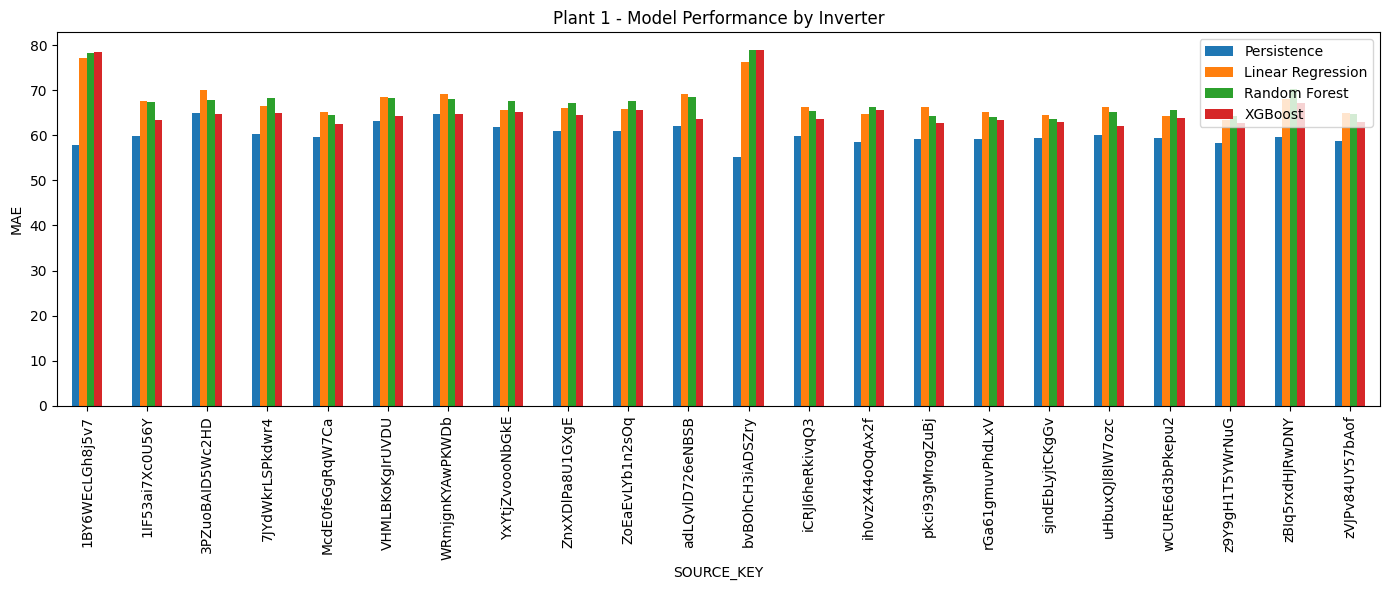

In [33]:
# What this cell does:
# Compare model MAE across individual inverters for Plant 1.

plant1_inverter_mae.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("SOURCE_KEY")
plt.ylabel("MAE")
plt.title("Plant 1 - Model Performance by Inverter")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

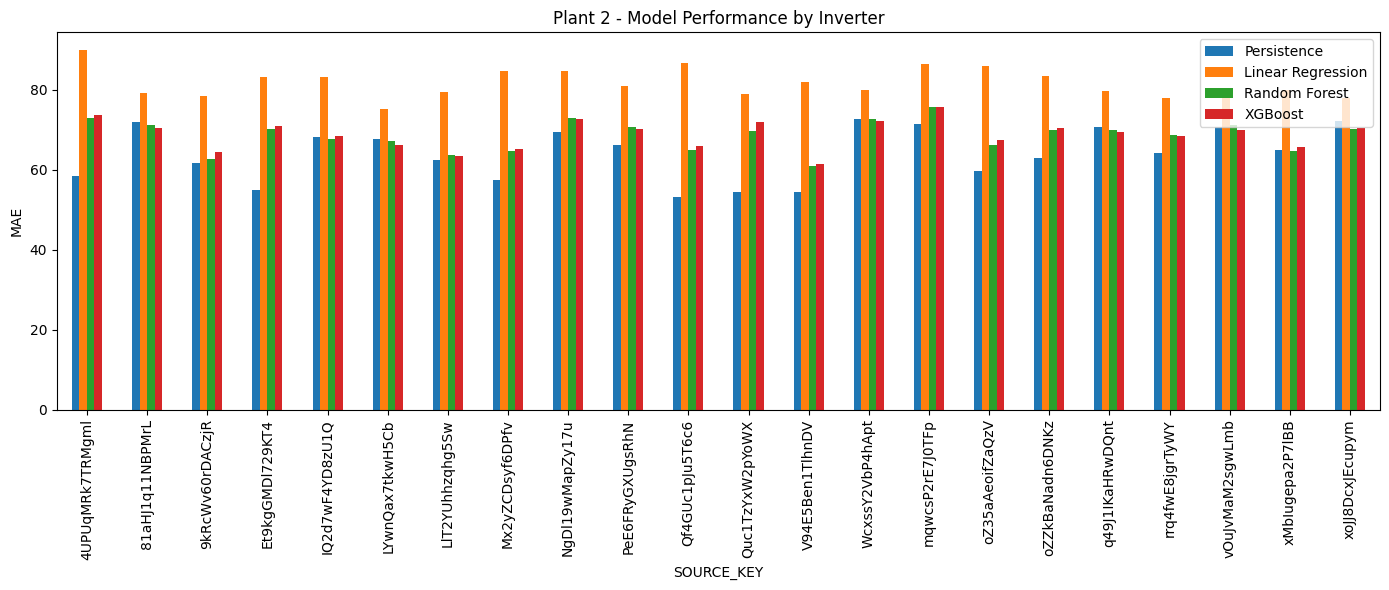

In [34]:
# What this cell does:
# Compare model MAE across individual inverters for Plant 2.

plant2_inverter_mae.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("SOURCE_KEY")
plt.ylabel("MAE")
plt.title("Plant 2 - Model Performance by Inverter")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# What this cell does:
# Calculate and summarize final TEST performance
# for all models on Plant 1 and Plant 2.

def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


# -----------------------------
# Plant 1
# -----------------------------

p1_persistence = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Persistence"]
)

p1_linear = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Linear_Regression"]
)

p1_rf = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Random_Forest"]
)

p1_xgb = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["XGBoost"]
)


# -----------------------------
# Plant 2
# -----------------------------

p2_persistence = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Persistence"]
)

p2_linear = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Linear_Regression"]
)

p2_rf = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Random_Forest"]
)

p2_xgb = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["XGBoost"]
)


# -----------------------------
# Create final comparison table
# -----------------------------

final_model_results = pd.DataFrame({

    "Plant": [
        "Plant 1",
        "Plant 1",
        "Plant 1",
        "Plant 1",
        "Plant 2",
        "Plant 2",
        "Plant 2",
        "Plant 2"
    ],

    "Model": [
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        p1_persistence[0],
        p1_linear[0],
        p1_rf[0],
        p1_xgb[0],
        p2_persistence[0],
        p2_linear[0],
        p2_rf[0],
        p2_xgb[0]
    ],

    "RMSE": [
        p1_persistence[1],
        p1_linear[1],
        p1_rf[1],
        p1_xgb[1],
        p2_persistence[1],
        p2_linear[1],
        p2_rf[1],
        p2_xgb[1]
    ],

    "R2": [
        p1_persistence[2],
        p1_linear[2],
        p1_rf[2],
        p1_xgb[2],
        p2_persistence[2],
        p2_linear[2],
        p2_rf[2],
        p2_xgb[2]
    ]
})

final_model_results

,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.149400,113.231793,0.911274
1,Plant 1,Linear Regression,67.293764,110.668774,0.915245
2,Plant 1,Random Forest,67.528151,131.682341,0.880003
3,Plant 1,XGBoost,65.361558,129.558902,0.883842
4,Plant 2,Persistence,64.053122,132.336049,0.802912
5,Plant 2,Linear Regression,81.552082,148.343718,0.752348
6,Plant 2,Random Forest,68.538695,141.018397,0.776203
7,Plant 2,XGBoost,68.817973,142.874223,0.770273


In [36]:
# What this cell does:
# Save the final test-set model comparison.

METRICS_PATH = "../outputs/metrics/"
os.makedirs(METRICS_PATH, exist_ok=True)

final_model_results.to_csv(
    METRICS_PATH + "final_model_results.csv",
    index=False
)

print("Final model results saved successfully.")

Final model results saved successfully.


In [37]:
# What this cell does:
# Find the model with the lowest MAE separately
# for Plant 1 and Plant 2.

best_models = (
    final_model_results
    .loc[final_model_results.groupby("Plant")["MAE"].idxmin()]
    .reset_index(drop=True)
)

print("Best model based on MAE:")
display(best_models)

Best model based on MAE:


,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.149400,113.231793,0.911274
1,Plant 2,Persistence,64.053122,132.336049,0.802912


## Evaluation uses the weather-aware models

The Linear Regression, Random Forest, and XGBoost models are trained with the current-time weather features plus time and historical-power features. This notebook evaluates those same saved models using the exact same feature list. Persistence remains a weather-free baseline.
